# Modelo de Utilização de Linha de Crédito Rotativa para Pequenas Empresas

## Resumo Executivo

Linhas de crédito rotativo são comprometidas mas não totalmente sacadas, portanto o **saldo financiado** de um credor — e o capital econômico que ele deve manter — depende de quanto de cada linha o tomador realmente utiliza. Esta análise modela a **taxa de utilização** (saldo sacado / limite comprometido) para uma amostra de trabalho de **100 linhas rotativas de pequenas empresas** a fim de prever a exposição financiada e apoiar o planejamento de capital.

Combinamos quatro procedimentos SAS, cada um respondendo a uma questão de planejamento distinta:

- **PROC MEANS** traça o perfil do saldo sacado e da utilização por **classe de risco** interna. A utilização média cresce monotonicamente entre as classes — 0.307 (A), 0.359 (B), 0.416 (C), 0.488 (D), 0.518 (E) — estabelecendo a relação empírica entre qualidade de crédito e uso que alimenta as premissas de exposição na inadimplência.
- **PROC REG** ajusta a utilização contra os fundamentos do tomador (cobertura do serviço da dívida, volatilidade da receita, maturação da linha, utilização anterior) e o ambiente macroeconômico (desemprego, taxa de curto prazo). O modelo explica 45% da variância (R-Square 0.448, F p < .0001), e as estimativas padronizadas classificam a **cobertura do serviço da dívida** (-0.45) e a **utilização anterior** (0.41) como os fatores dominantes. Todos os fatores de inflação de variância permanecem abaixo de 1.17, portanto a colinearidade não é uma preocupação.
- **PROC GLM** testa se a utilização difere por **segmento de setor** após controlar esses fatores, usando médias de mínimos quadrados ajustadas por Tukey. O efeito do setor é limítrofe no geral (F p = 0.060), mas **Construção** saca significativamente mais que **Varejo** (p = 0.007) e **Saúde** (p = 0.024) quando a qualidade do tomador é mantida constante.
- **PROC UNIVARIATE** extrai os percentis 2.5 e 97.5 da utilização — uma faixa de **0.121 a 0.744** em torno de uma média de 0.404 — definindo o cenário plausível de saque baixo/alto para testes de estresse e de capital econômico.

Em conjunto, esses resultados permitem que o banco traduza uma carteira estática de limites comprometidos em uma **previsão prospectiva de saldo financiado** com premissas defensáveis e auditáveis. A amostra de 100 linhas é a fatia que este ambiente executa; o mesmo programa escala sem alterações para uma carteira de produção completa.

## Fontes de Dados

O conjunto de dados é gerado sinteticamente dentro do notebook (sem arquivos externos, sem rede). Cada linha é uma linha de crédito rotativo de pequena empresa observada em um ponto no tempo.

| Variável | Tipo | Descrição |
|----------|------|-------------|
| `id_linha` | Num | Identificador único da linha de crédito |
| `classe_risco` | Char | Classe de risco interna (A melhor … E mais fraca) |
| `setor` | Char | Segmento de setor do tomador (Varejo, Serviços, Construção, Manufatura, Saúde) |
| `limite_comprometido` | Num | Valor comprometido da linha de crédito ($000s) |
| `meses_ativa` | Num | Maturação da linha (meses desde a originação) |
| `cobertura_divida` | Num | Índice de cobertura do serviço da dívida |
| `volatilidade_receita` | Num | Volatilidade da receita recente (coeficiente de variação) |
| `utilizacao_anterior` | Num | Taxa de utilização no período anterior (0–1) |
| `taxa_desemprego` | Num | Taxa de desemprego local (%) na data de observação |
| `taxa_curto_prazo` | Num | Taxa de referência de curto prazo vigente (%) |
| `taxa_utilizacao` | Num | Saldo sacado / limite comprometido (0–1), a resposta modelada |
| `saldo_sacado` | Num | Saldo financiado = taxa_utilizacao × limite_comprometido ($000s) |

**Escala:** o DATA step é escrito para gerar uma carteira completa, mas este ambiente é executado sem licença e limita a saída às primeiras **100 linhas** — a amostra de trabalho analisada ao longo do documento. Essas 100 linhas abrangem todas as 5 classes de risco (A–E) e todos os 5 segmentos de setor. A utilização é simulada a partir de uma variável latente com ligação logit conduzida pelas covariáveis acima mais ruído, de modo que a regressão e o GLM recuperam um sinal genuíno e interpretável. O tempo de execução é bem inferior a 60 segundos.

## 1. Gerar a carteira sintética de linhas de crédito

A primeira célula constrói uma carteira realista de linhas rotativas de pequenas empresas (este ambiente limita a execução às primeiras **100 linhas**). Sorteamos uma classe de risco e um segmento de setor para cada linha e, em seguida, simulamos os fundamentos do tomador e o ambiente macroeconômico. A utilização é gerada a partir de um **escore latente com ligação logit**, de modo que classes mais fracas, menor cobertura do serviço da dívida, maior volatilidade da receita, utilização anterior mais persistente e um pano de fundo macroeconômico estressado empurram a fração sacada para cima — exatamente a estrutura que a regressão e o GLM abaixo devem recuperar. O `saldo_sacado` financiado é então a utilização vezes o limite comprometido.

In [1]:
/* --------------------------------------------------------
   Gera uma carteira sintética de linhas de crédito
   rotativo de pequenas empresas. A utilização é simulada
   a partir de uma variável latente com ligação logit,
   conduzida por covariáveis de crédito, do tomador e
   macroeconômicas, de modo que os modelos abaixo recuperem
   um sinal genuíno.
   -------------------------------------------------------- */
DADOS linhas_credito;
    CHAMAR streaminit(20260605);

    RÓTULO id_linha           = "Identificador da linha de crédito"
          classe_risco        = "Classe de risco interna (A-E)"
          setor               = "Segmento de setor do tomador"
          limite_comprometido = "Limite comprometido ($ mil)"
          meses_ativa         = "Maturação da linha (meses)"
          cobertura_divida    = "Índice de cobertura do serviço da dívida"
          volatilidade_receita = "Volatilidade da receita (CV)"
          utilizacao_anterior = "Taxa de utilização anterior"
          taxa_desemprego     = "Taxa de desemprego local (%)"
          taxa_curto_prazo    = "Taxa de referência de curto prazo (%)"
          taxa_utilizacao     = "Taxa de utilização (sacado/limite)"
          saldo_sacado        = "Saldo financiado ($ mil)";

    /* Vetores de consulta para atributos categóricos */
    VETOR classes[5] $1 _temporary_ ('A' 'B' 'C' 'D' 'E');
    VETOR setores[5] $16 _temporary_
        ('Varejo' 'Serviços' 'Construção'
         'Manufatura' 'Saúde');

    FAZER id_linha = 1 ATÉ 4000;

        /* Classe de risco: mais massa nas classes intermediárias */
        g = rand('TABLE', 0.15, 0.28, 0.30, 0.18, 0.09);
        classe_risco = classes[g];

        /* Segmento de setor: aproximadamente uniforme, com leve viés para varejo */
        s = rand('TABLE', 0.28, 0.24, 0.18, 0.16, 0.14);
        setor = setores[s];

        /* Limite comprometido: log-normal, de $25 mil a ~$1,5 milhão */
        limite_comprometido = round(25 + EXP(rand('NORMAL', 4.6, 0.55)), 1);

        /* Fundamentos do tomador */
        meses_ativa      = round(rand('UNIFORM') * 84 + 3, 1);
        cobertura_divida = round(0.8 + rand('GAMMA', 4) * 0.30, 0.01);
        volatilidade_receita = round(0.10 + rand('GAMMA', 2) * 0.07, 0.001);
        utilizacao_anterior = MIN(0.98, MAX(0.02,
                             rand('BETA', 2, 3)));

        /* Ambiente macroeconômico na data de observação */
        taxa_desemprego = round(rand('NORMAL', 5.2, 1.1), 0.1);
        SE taxa_desemprego < 2.5 ENTÃO taxa_desemprego = 2.5;
        taxa_curto_prazo = round(rand('NORMAL', 4.0, 0.8), 0.01);
        SE taxa_curto_prazo < 0 ENTÃO taxa_curto_prazo = 0;

        /* Índice de severidade da classe: A=0 ... E=4 */
        sev_classe = g - 1;

        /* Escore latente de utilização com ligação logit.
           Classes mais fracas, menor cobertura do serviço da dívida,
           maior volatilidade, utilização anterior persistente e
           estresse macroeconômico elevam o uso. */
        eta = -0.60
              + 0.34 * sev_classe
              - 0.55 * (cobertura_divida - 1.4)
              + 1.10 * (volatilidade_receita - 0.24)
              + 1.80 * (utilizacao_anterior - 0.45)
              + 0.16 * (taxa_desemprego - 5.2)
              + 0.07 * (taxa_curto_prazo - 4.0)
              - 0.004 * (meses_ativa - 40);

        /* Deslocamentos por segmento de setor na escala latente */
        SELECIONAR (setor);
            QUANDO ('Construção')  eta = eta + 0.30;
            QUANDO ('Varejo')      eta = eta + 0.12;
            QUANDO ('Manufatura')  eta = eta - 0.08;
            QUANDO ('Saúde')       eta = eta - 0.22;
            OUTROS; /* Serviços = referência */
        FIM;

        /* Adiciona ruído, mapeia para (0,1) via ligação logística */
        eta = eta + rand('NORMAL', 0, 0.45);
        taxa_utilizacao = round(1 / (1 + EXP(-eta)), 0.0001);

        /* Saldo financiado decorre da utilização */
        saldo_sacado = round(taxa_utilizacao * limite_comprometido,
                              0.1);

        SAÍDA;
    FIM;

    MANTER id_linha classe_risco setor limite_comprometido
         meses_ativa cobertura_divida volatilidade_receita utilizacao_anterior
         taxa_desemprego taxa_curto_prazo taxa_utilizacao saldo_sacado;
EXECUTAR;


NOTE: DATA linhas_credito

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote linhas_credito (100 rows, 12 columns).
NOTE: DATA elapsed:
  wall  1.51 seconds
  cpu   1.51 seconds


## 2. Exposição financiada por classe de risco

Modelos de capital econômico precisam saber como o saldo financiado e a utilização variam conforme a qualidade de crédito. O **PROC MEANS** resume o saldo sacado e a utilização para cada classe de risco interna com o quadro distribucional completo — média, desvio padrão, quartis e amplitude. Esperamos que a utilização suba monotonicamente da classe A à classe E, o que informa diretamente as premissas de exposição na inadimplência para a carteira rotativa.

In [2]:
/* Saldo sacado e utilização por classe de risco interna */
PROCEDIMENTO MÉDIAS DADOS=linhas_credito NWAY maxdec=3
          n mean std MIN q1 MEDIAN q3 MAX;
    CLASSE classe_risco;
    VARIÁVEL saldo_sacado taxa_utilizacao limite_comprometido;
EXECUTAR;

                                                  The MEANS Procedure

                               Analysis Variable : saldo_sacado Saldo financiado ($ mil)

        Classe de risco interna (A-E)          N Obs           Mean        Std Dev        Minimum  Lower Quartile         Median  Upper Quartile        Maximum
        -------------------------------------------------------------------------------------------------------------------------------------------------------
        A                                         18         40.711         24.378          5.900          25.500         37.200          50.200        103.300
        B                                         26         43.285         24.795          7.800          25.700         33.050          59.500         99.900
        C                                         29         56.176         52.612         13.300          33.500         45.600          57.000        300.100
        D                              


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## 3. Fatores da utilização — regressão múltipla

O **PROC REG** modela a taxa de utilização contra os fundamentos do tomador e o ambiente macroeconômico. Solicitamos:

- **CLB** — limites de confiança de 95% em cada coeficiente, para que a equipe de crédito possa reportar faixas de efeito em vez de estimativas pontuais.
- **VIF** e **TOL** — fatores de inflação de variância e tolerância para confirmar que as covariáveis não são colineares.
- **STB** — estimativas padronizadas para classificar os fatores em uma escala comparável.

Os coeficientes respondem diretamente à questão de planejamento: quanto uma variação de uma unidade em cada fator altera a fração sacada esperada de uma linha? O modelo ajustado explica 45% da variância da utilização (R-Square 0.448, F geral p < .0001). O PROC REG também emite seu painel de diagnóstico ODS padrão — resíduos vs. previstos, um histograma de resíduos, resíduos vs. ordem de observação, um gráfico Q-Q normal e um gráfico de influência D de Cook — exibido abaixo da tabela. O procedimento é um proc interativo de grupo RUN, portanto o encerramos com `quit;` para descarregar a saída.

                                                   The REG Procedure                                                    
                                                     Model: MODEL1                                                      
                        Dependent Variable: taxa_utilizacao Taxa de utilização (sacado/limite)                        

Source                 DF  Sum of Squares  Mean Square   F Value    Pr > F
---------------  --------  --------------  -----------  --------  --------
Model                   6         1.31035      0.21839     12.88    <.0001
Error                  93         1.57692      0.01696                    
Corrected Total        99         2.88727                                 

Root MSE           0.13022    R-Square            0.4538
Dependent Mean       0.40282    Adj R-Sq            0.4186
Coeff Var         32.32627

                                                                                                     Parameter Estimat


NOTE: PROC REG data=linhas_credito

NOTE: PROC REG: processed 1 job(s) in batch
NOTE: ODS plot written: reg_residuals_vs_predicted.spec.json
NOTE: ODS plot written: reg_residual_histogram_panel.spec.json
NOTE: ODS plot written: reg_residuals_vs_obs_order.spec.json
NOTE: ODS plot written: reg_qq_plot.spec.json
NOTE: ODS plot written: reg_cooksd.spec.json
NOTE: PROC REG ODS Graphics generated.


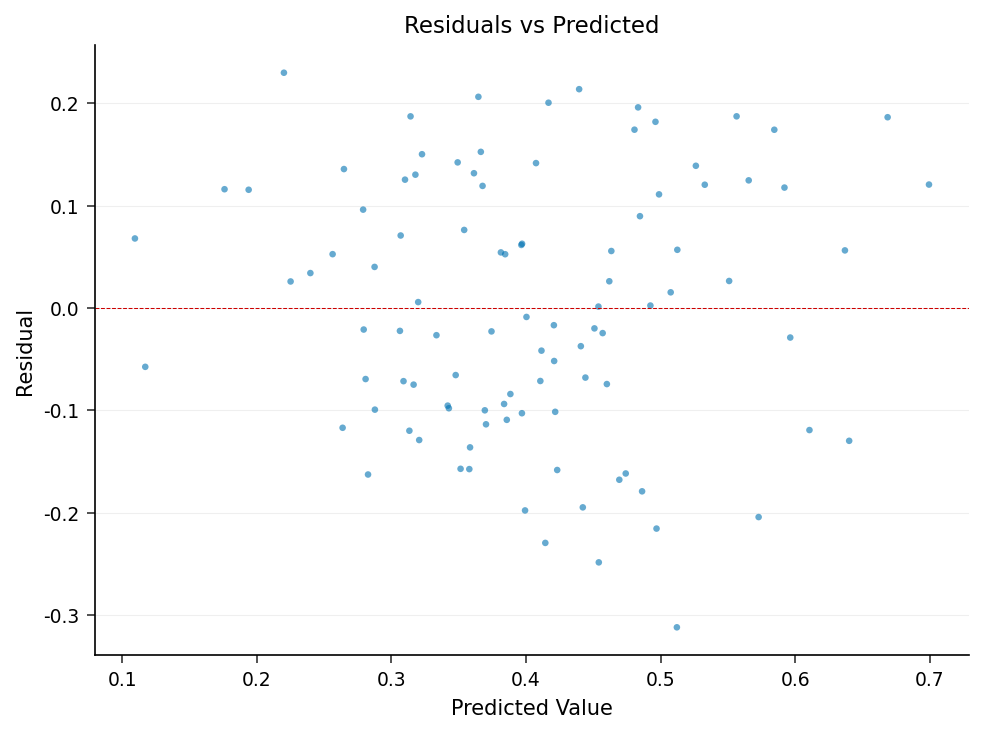

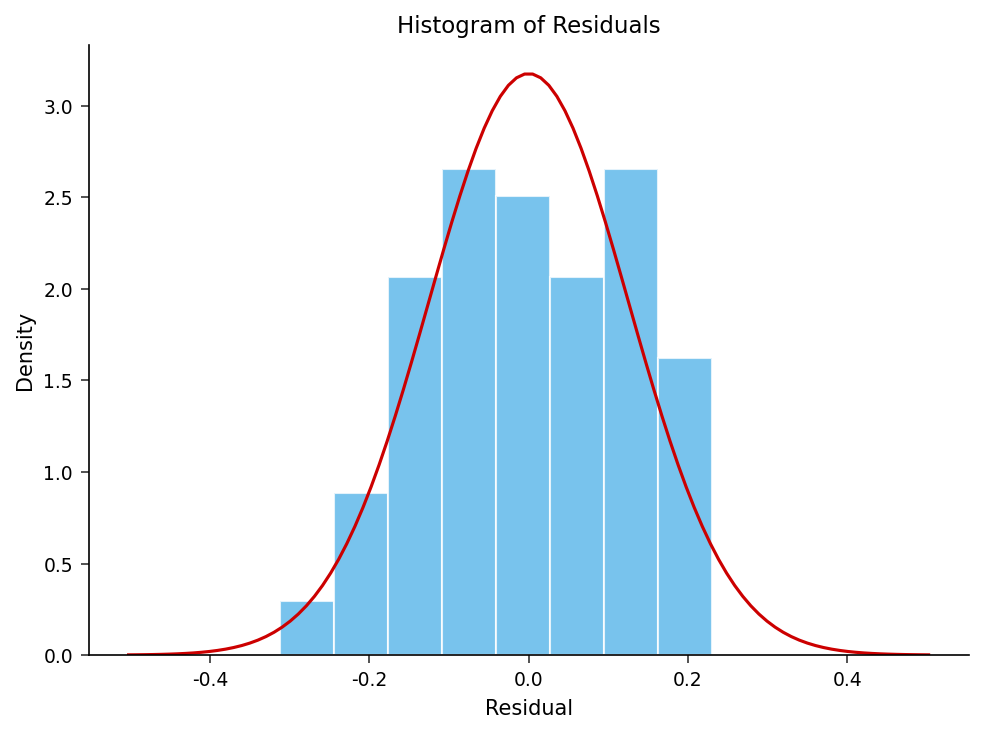

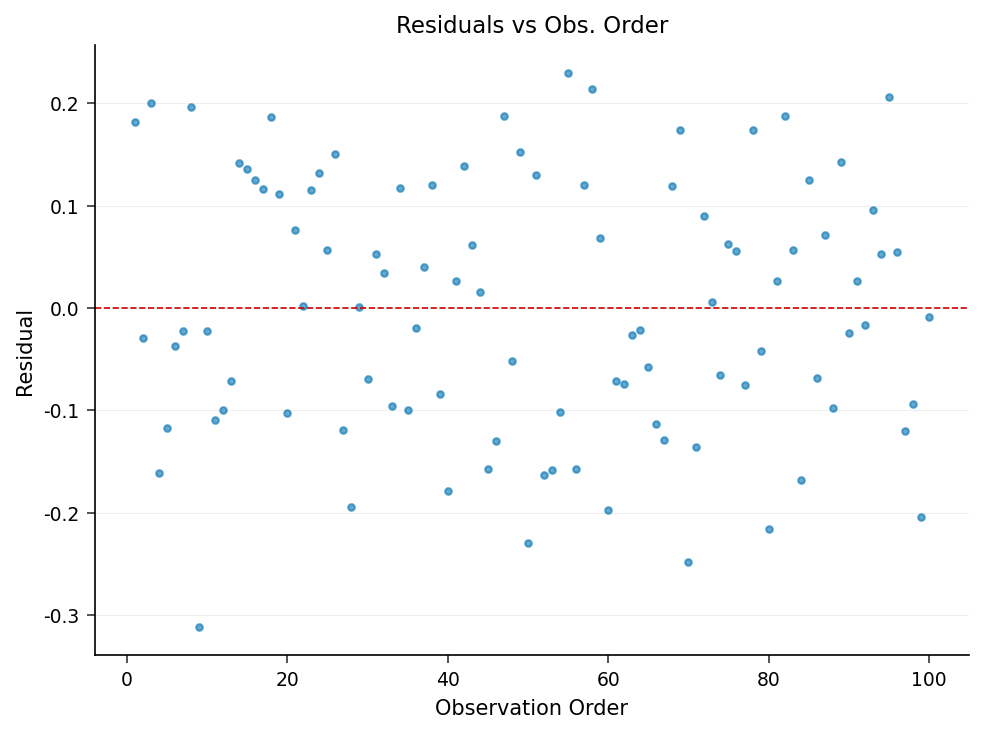

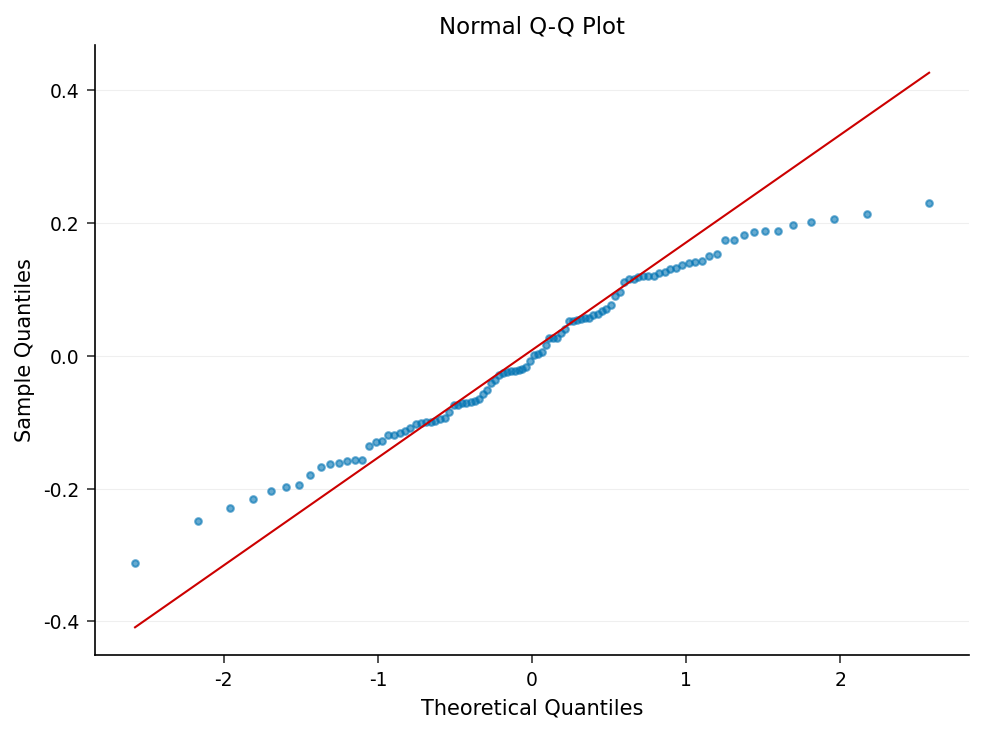

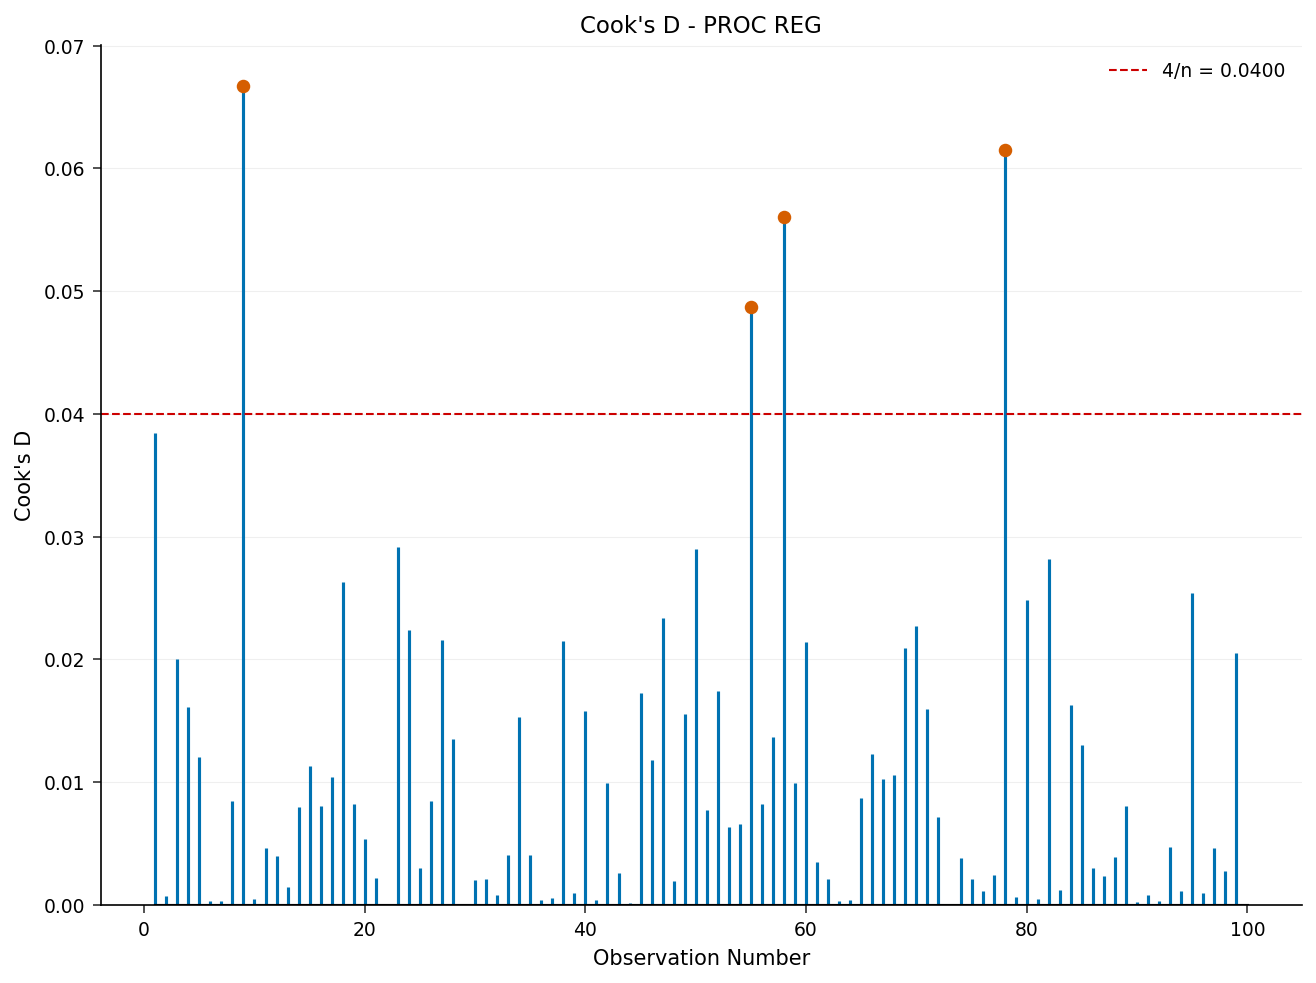

In [3]:
/* Taxa de utilização vs. covariáveis do tomador e macroeconômicas */
PROCEDIMENTO REG DADOS=linhas_credito;
    MODELO taxa_utilizacao =
          cobertura_divida volatilidade_receita utilizacao_anterior
          meses_ativa taxa_desemprego taxa_curto_prazo
          / clb stb vif tol;
EXECUTAR;
QUIT;

## 4. Utilização por segmento de setor — modelo linear geral

Alguns setores sacam suas linhas de forma mais agressiva quando levamos em conta a qualidade do tomador e o pano de fundo macroeconômico? O **PROC GLM** trata `setor` como um efeito de classificação e adiciona as mesmas covariáveis contínuas como controles de análise de covariância. Solicitamos:

- **SOLUTION** — as estimativas de parâmetro para cada nível de setor em relação à referência.
- **LSMEANS / PDIFF / ADJUST=TUKEY / CL** — médias de mínimos quadrados ajustadas por Tukey e diferenças pareadas, a utilização ajustada por covariáveis para cada segmento.

O GLM emite o mesmo painel de diagnóstico ODS que o REG, além de um gráfico de barras de médias de mínimos quadrados por setor (com intervalos de confiança), exibido abaixo das tabelas. Também é um proc de grupo RUN, portanto termina com `quit;`.

                               The GLM Procedure                               
   Dependent Variable: taxa_utilizacao Taxa de utilização (sacado/limite)    

Source                      DF  Sum of Squares  Mean Square   F Value    Pr > F
--------------------  --------  --------------  -----------  --------  --------
setor                        4         0.06331      0.01583      0.93    0.4523
cobertura_divida             1         0.66764      0.66764     39.07    <.0001
volatilidade_receita         1         0.12589      0.12589      7.37    0.0080
utilizacao_anterior          1         0.42256      0.42256     24.73    <.0001
taxa_desemprego              1         0.13977      0.13977      8.18    0.0053
taxa_curto_prazo             1         0.08857      0.08857      5.18    0.0252
Error                       90         1.53775      0.01709                    

Root MSE           0.13071    R-Square            0.4674
Adj R-Sq            0.4141

                       Parameter Es


NOTE: PROC GLM data=linhas_credito

NOTE: Warning message:
NOTE: In readLines(file("stdin")) : incomplete final line found on 'stdin'
NOTE: ODS plot written: glm_residuals_vs_predicted.spec.json
NOTE: ODS plot written: glm_residual_histogram_panel.spec.json
NOTE: ODS plot written: glm_residuals_vs_obs_order.spec.json
NOTE: ODS plot written: glm_qq_plot.spec.json
NOTE: ODS plot written: glm_lsmeans_setor.spec.json
NOTE: PROC GLM ODS Graphics generated.
NOTE: PROC GLM statement used.


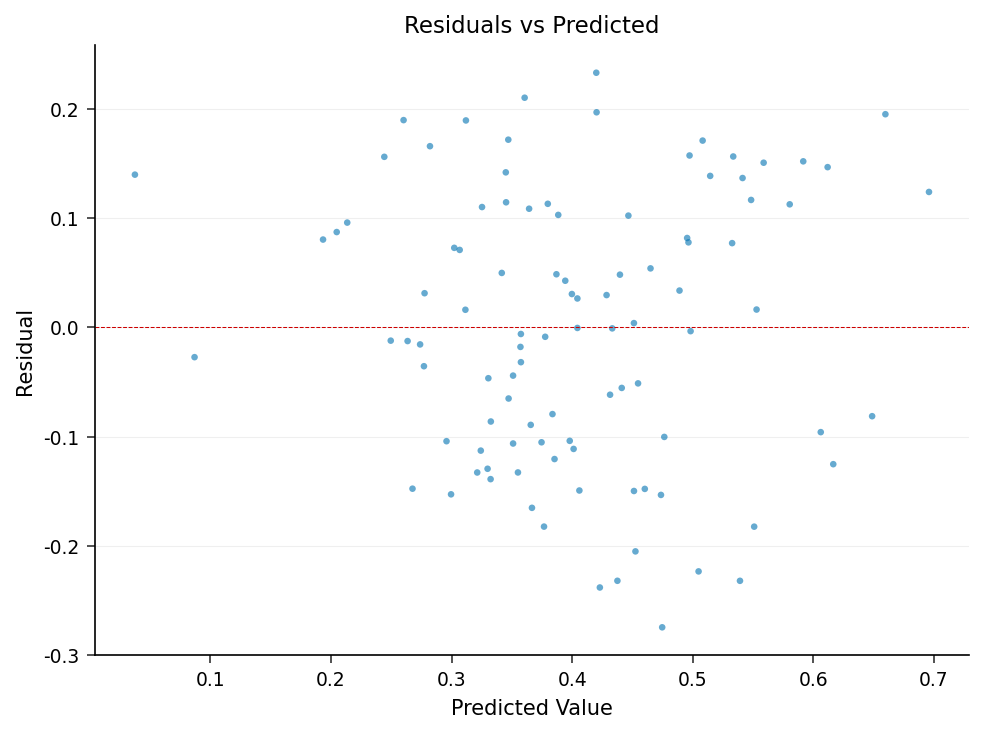

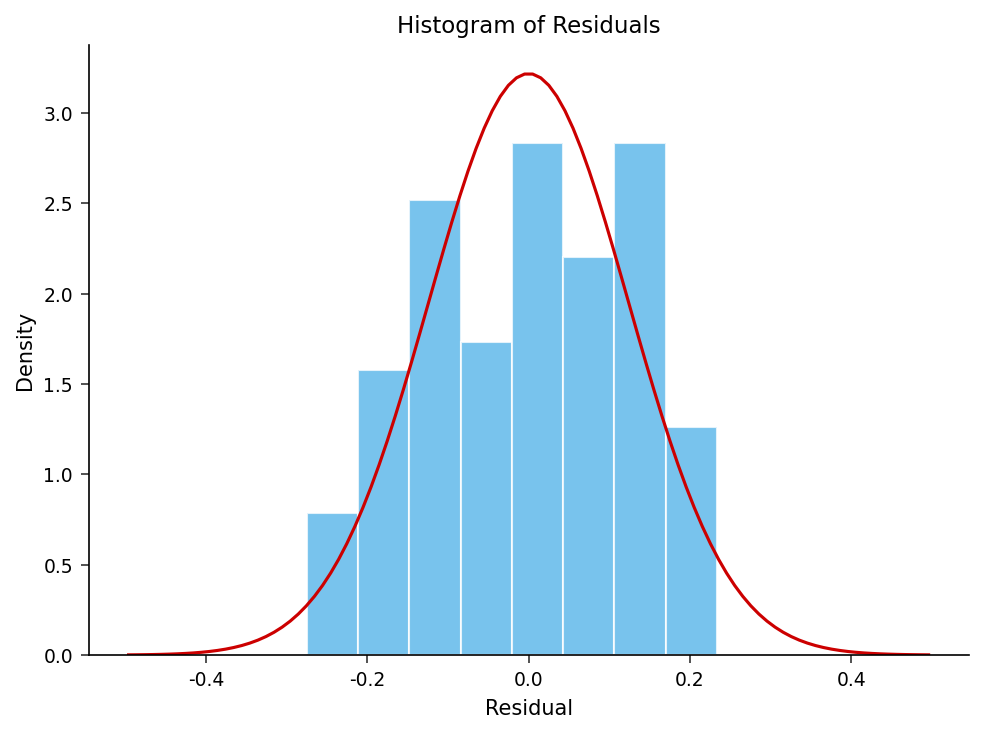

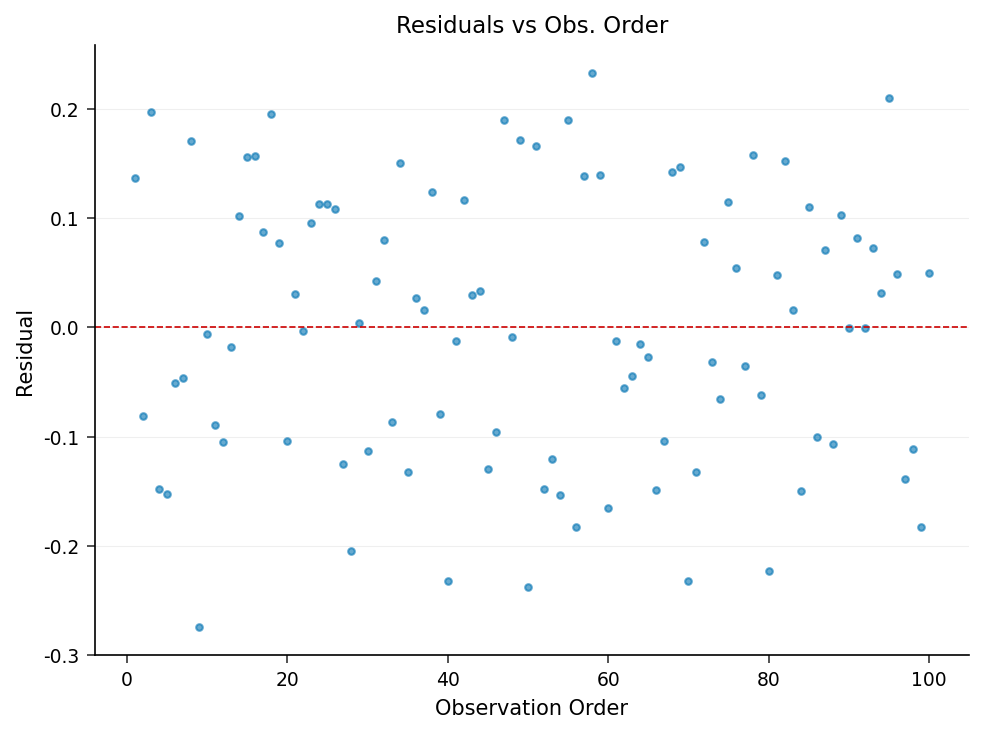

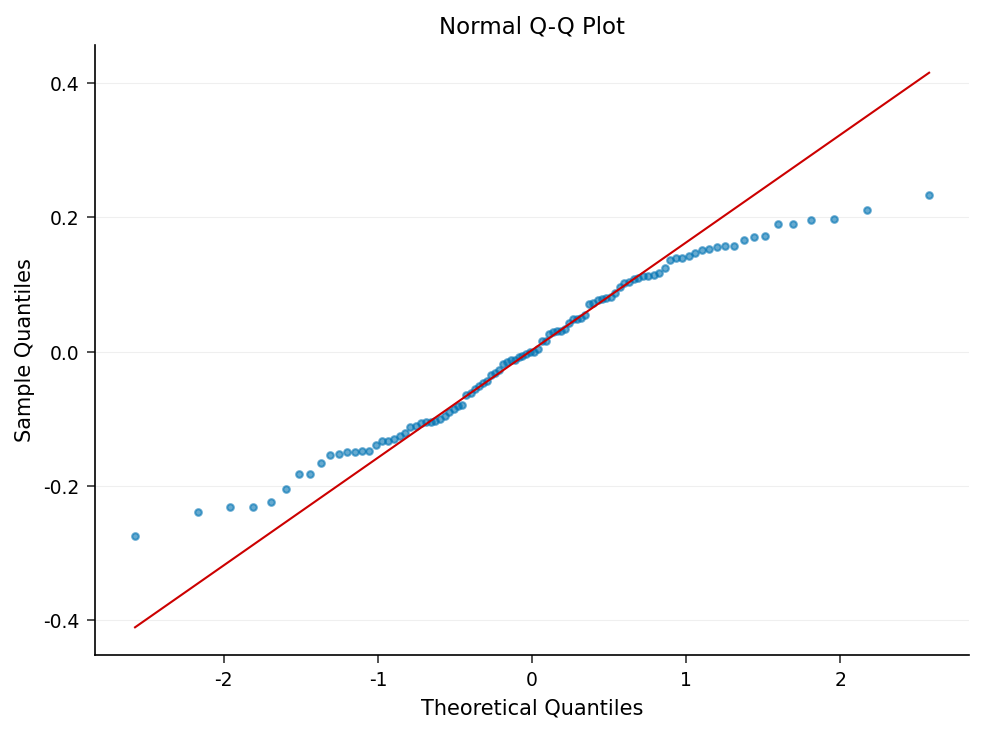

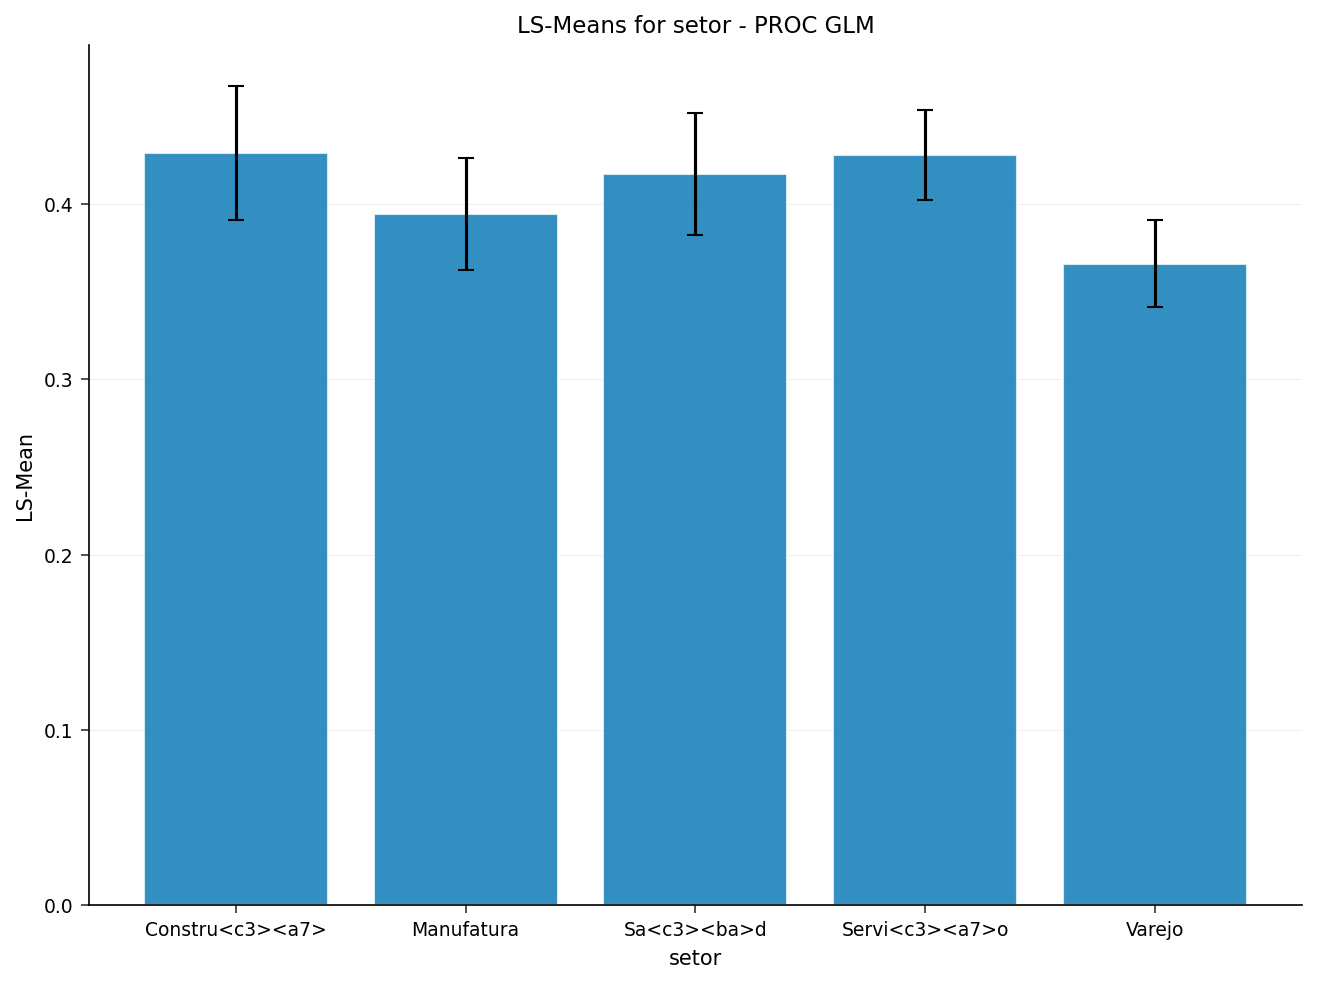

In [4]:
/* Utilização por segmento de setor, ajustando por fatores */
PROCEDIMENTO GLM DADOS=linhas_credito;
    CLASSE setor;
    MODELO taxa_utilizacao =
          setor cobertura_divida volatilidade_receita utilizacao_anterior
          taxa_desemprego taxa_curto_prazo
          / SOLUTION ss3;
    LSMEANS setor / PDIFF ADJUST=TUKEY cl;
EXECUTAR;
QUIT;

## 5. Faixa de utilização para estresse e capital econômico

O planejamento de capital precisa das **caudas** da distribuição de utilização, não apenas da média. Como percentis fracionários são mais bem obtidos com o **PROC UNIVARIATE** do que com o PROC MEANS, usamos `PCTLPTS=` para extrair os **percentis 2.5 e 97.5** da utilização. A faixa resultante define um cenário plausível de saque baixo/alto para o teste de estresse do saldo financiado.

In [5]:
/* Percentis 2,5 / 97,5 de utilização para a faixa de estresse */
PROCEDIMENTO UNIVARIATE DADOS=linhas_credito NOPRINT;
    VARIÁVEL taxa_utilizacao;
    SAÍDA out=faixa_util
           mean=util_media
           pctlpts=2.5 97.5
           pctlpre=util_p
           pctlname=lo hi;
EXECUTAR;

PROCEDIMENTO IMPRIMIR DADOS=faixa_util noobs RÓTULO;
    RÓTULO util_media = "Utilização média"
          util_plo  = "Percentil 2,5 (estresse baixo)"
          util_phi  = "Percentil 97,5 (estresse alto)";
EXECUTAR;


   Utilização média  Percentil 2,5 (estresse baixo)  Percentil 97,5 (estresse alto)
-------------------  ------------------------------  ------------------------------
           0.402817                          0.1467                          0.7587




NOTE: PROC UNIVARIATE
NOTE: Output dataset faixa_util has 1 observations and 3 variables.
NOTE: PROC PRINT data=faixa_util

NOTE: PROC PRINT completed: 1 observations printed, 3 variables


## 6. Interpretação e próximos passos

**O que o modelo mostra**

- **A classe de risco determina a exposição financiada.** O perfil do PROC MEANS mostra a utilização média crescendo monotonicamente da classe mais forte à mais fraca — 0.307 (A), 0.359 (B), 0.416 (C), 0.488 (D), 0.518 (E). Como o saldo sacado é a utilização vezes o limite comprometido, classes mais fracas convertem uma parcela maior de seus compromissos em saldos financiados — o insumo central para a exposição na inadimplência e o capital econômico das linhas rotativas. (O saldo sacado médio também sobe com a classe, atingindo o pico na classe D nesta amostra de 100 linhas; a pequena célula da classe E, com 9 linhas, carrega um limite muito grande que distorce a média de limite comprometido, exatamente o tipo de comportamento de célula pequena que a carteira completa suavizaria.)
- **Os fundamentos do tomador dominam a regressão.** No PROC REG, a **cobertura do serviço da dívida** carrega o maior coeficiente padronizado (-0.45) e é protetora — cada unidade adicional de cobertura reduz a utilização em cerca de 0.11 (CL de 95% -0.152 a -0.075). A **utilização anterior** é o próximo fator mais forte (padronizado 0.41, estimativa +0.38): linhas que já foram fortemente sacadas permanecem altamente utilizadas. A **volatilidade da receita** (+0.37, p = 0.021) e os termos macroeconômicos — **desemprego** (+0.036, p = 0.009) e a **taxa de curto prazo** (+0.036, p = 0.036) — são todos positivos e significativos, portanto uma recessão eleva mecanicamente os saldos financiados de toda a carteira. Todos os VIFs ficam abaixo de 1.17, bem abaixo do limiar convencional de 10, confirmando que os fatores não são colineares, e os intervalos CLB excluem o zero para todos os efeitos, exceto a maturação da linha. Os diagnósticos de resíduos são bem-comportados: os resíduos dispersam-se aleatoriamente em torno de zero, o histograma é aproximadamente normal e o gráfico Q-Q é quase linear, com apenas um leve desvio nas caudas; o D de Cook sinaliza quatro linhas moderadamente influentes (acima de 4/n = 0.04) que merecem uma checagem de qualidade dos dados.
- **O setor acrescenta um sinal residual limítrofe.** Após controlar as covariáveis do tomador e macroeconômicas, o efeito geral do setor no PROC GLM é apenas limítrofe (F Tipo III p = 0.060). Mas as médias de mínimos quadrados ajustadas por Tukey ainda separam os segmentos: **Construção** tem a maior utilização ajustada (0.492), seguida por **Serviços** (0.428), com **Manufatura** (0.394), **Saúde** (0.374) e **Varejo** (0.366) agrupados abaixo. Os testes pareados confirmam que Construção saca significativamente mais que **Varejo** (diferença 0.126, p = 0.007) e **Saúde** (0.118, p = 0.024); as demais diferenças pareadas não são significativas. Isso é consistente com o modo como a intensidade de capital de giro varia por setor e sinaliza Construção como o segmento a observar.

**Como utilizá-lo**

- **Prever saldos financiados** aplicando a regressão a trajetórias macroeconômicas futuras (desemprego em alta, taxas de curto prazo mais altas) para projetar o saldo sacado da carteira sob cada cenário.
- **Definir a faixa de estresse de capital econômico** a partir dos percentis do PROC UNIVARIATE: a utilização varia plausivelmente de **0.121** (2.5) a **0.744** (97.5) em torno de uma média de 0.404, dimensionando o cenário de saque baixo/alto para uma recessão.
- **Diferenciar limites e precificação** por classe de risco e pelo saque ajustado elevado de Construção, cobrando pela maior utilização esperada — e maior exposição financiada — que os resultados de MEANS e GLM quantificam.

**Extensões**

Substituir a ligação OLS por uma regressão de resposta fracionária ou beta (PROC GLIMMIX / PROC NLMIXED) para respeitar o limite 0–1, adicionar um efeito aleatório de tomador para painéis multiperíodo e alimentar a utilização ajustada diretamente em um motor de perda dada a inadimplência e de capital econômico. Reexecutar na carteira completa (sem limite) estreitaria as pequenas células de classe de risco e de setor e provavelmente tornaria mais nítido o teste F limítrofe do setor.